#  Quantitative Foundations

End-to-end walkthrough of the Monte Carlo GBM engine: volatility estimation,
simulation, statistics, theoretical comparison, confidence intervals,
convergence, and visualization, using the platform's default scenario.

**Default scenario**

| Parameter | Value |
|---|---|
| Initial Price (S0) | $100 |
| Drift (μ) | 8% |
| Volatility (σ) | 20% |
| Time Horizon (T) | 1 year |
| Steps (N) | 252 |
| Simulations (M) | 10,000 |
| Seed | 42 |


In [1]:
import sys
sys.path.append("..")  # so `app` package resolves when running from notebooks/

import numpy as np
import matplotlib.pyplot as plt

from app.models.market_parameters import MarketParameters
from app.models.simulation_parameters import SimulationParameters
from app.quant.volatility import historical_volatility, compute_log_returns
from app.quant.gbm import simulate_gbm
from app.quant.distributions import theoretical_gbm_distribution, percentage_error
from app.quant.statistics import descriptive_statistics, confidence_interval
from app.quant.monte_carlo import (
    run_simulation,
    convergence_study,
    run_sanity_checks,
    generate_validation_report,
)
from app.visualization.paths import plot_paths
from app.visualization.distributions import plot_terminal_histogram, plot_log_price_distribution
from app.visualization.convergence import plot_convergence

plt.rcParams["figure.figsize"] = (10, 6)


## 1. Market & Simulation Parameters

In [2]:
market = MarketParameters(
    initial_price=100.0,
    drift=0.08,
    volatility=0.20,
    time_horizon=1.0,
)

sim_params = SimulationParameters(
    steps=252,
    simulations=10_000,
    seed=42,
    mode="full",  # keep full paths for plotting in this notebook
)

market, sim_params


(MarketParameters(initial_price=100.0, drift=0.08, volatility=0.2, time_horizon=1.0, risk_free_rate=None),
 SimulationParameters(steps=252, simulations=10000, seed=42, mode='full'))

## 2. Historical Volatility Estimation (Illustrative)

Demonstrates the volatility module on a synthetically generated price series
(in production this would be real historical price data). Shows the
distinction between **log returns** (used for annualized volatility, because
they are exactly what GBM assumes is i.i.d. Normal) and **arithmetic
returns** (used for portfolio-level aggregation, not shown here).


In [3]:
rng = np.random.default_rng(0)
synthetic_daily_log_returns = rng.normal(loc=0.08/252, scale=0.20/np.sqrt(252), size=1500)
synthetic_prices = 100.0 * np.exp(np.cumsum(synthetic_daily_log_returns))
synthetic_prices = np.insert(synthetic_prices, 0, 100.0)

vol_report = historical_volatility(synthetic_prices, trading_days_per_year=252)
print(vol_report)


Historical Volatility Report
─────────────────────────────
Observations:            1500
Trading days / year:     252
Mean daily log return:   0.000127
Std daily log return:    0.012466
Annualized mean return:  3.1941%
Annualized volatility:   19.7888%
Min / Max log return:    -0.048811 / 0.038946



## 3. Run the GBM Monte Carlo Simulation

In [4]:
output = run_simulation(market, sim_params)
gbm_result = output.gbm_result

print(f"Price matrix shape: {gbm_result.price_paths.shape}  (steps+1 x simulations)")
print(output.statistics)


Price matrix shape: (253, 10000)  (steps+1 x simulations)
Descriptive Statistics
───────────────────────
n:          10000
Mean:       108.532519
Median:     106.271329
Std Dev:    21.985412
Variance:   483.358351
Skewness:   0.604689
Kurtosis:   0.616881 (excess)
Min / Max:  51.743949 / 219.449274
Std Error:  0.219854
Percentiles:
    1%: 66.413719
    5%: 76.233849
   10%: 82.134756
   25%: 93.043212
   50%: 106.271329
   75%: 121.854529
   90%: 137.430705
   95%: 147.918850
   99%: 168.882594


## 4. Theoretical vs. Simulated Comparison

In [5]:
theory = output.theoretical
print(f"Theoretical E[S_T]:  {theory.price_mean:.4f}")
print(f"Simulated   E[S_T]:  {output.statistics.mean:.4f}")
print(f"Percentage error:    {output.mean_percentage_error:.4f}%")
print()
print(f"Theoretical Std[S_T]: {theory.price_std:.4f}")
print(f"Simulated   Std[S_T]: {output.statistics.std:.4f}")
print(f"Percentage error:     {output.std_percentage_error:.4f}%")


Theoretical E[S_T]:  108.3287
Simulated   E[S_T]:  108.5325
Percentage error:    0.1881%

Theoretical Std[S_T]: 21.8842
Simulated   Std[S_T]: 21.9854
Percentage error:     0.4624%


## 5. Confidence Intervals

**Important:** this interval quantifies uncertainty in *our estimate of the
mean*, not the range future prices might occupy — that's what the
percentiles below are for.


In [6]:
for level, ci in sorted(output.statistics.confidence_intervals.items()):
    print(ci)


90% CI: [108.1709, 108.8941] (point estimate 108.5325, SE 0.219854)
95% CI: [108.1016, 108.9634] (point estimate 108.5325, SE 0.219854)
99% CI: [107.9662, 109.0988] (point estimate 108.5325, SE 0.219854)


## 6. Visualizations

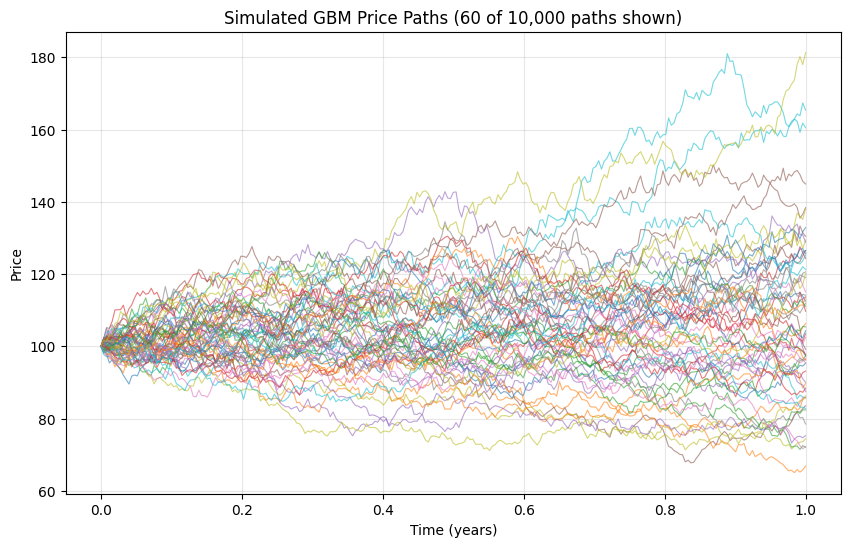

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
plot_paths(gbm_result.time_grid, gbm_result.price_paths, n_paths_to_plot=60, seed=1, ax=ax)
plt.show()


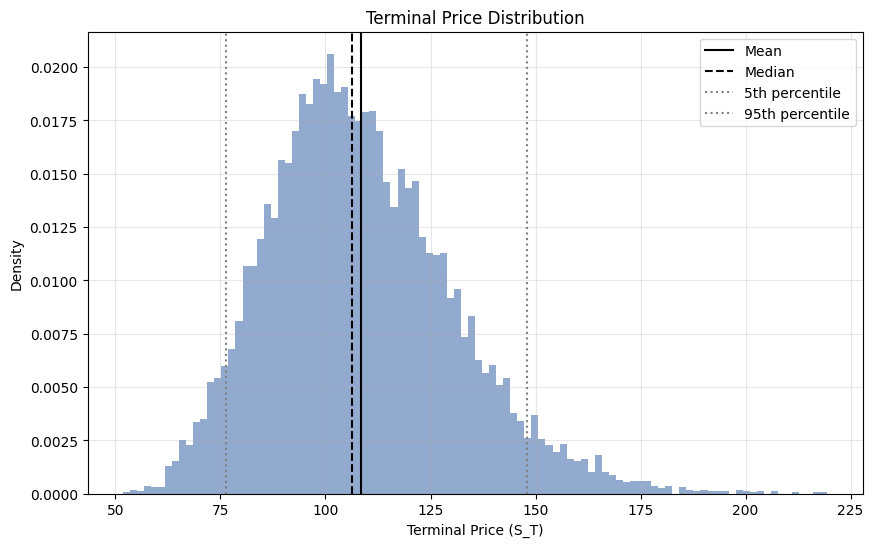

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
plot_terminal_histogram(gbm_result.terminal_prices, output.statistics, ax=ax)
plt.show()


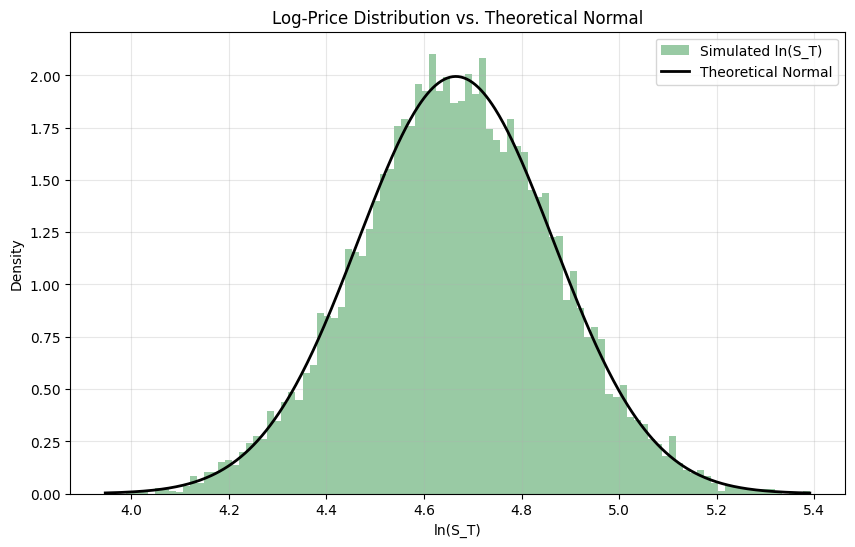

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
plot_log_price_distribution(gbm_result.terminal_prices, theory, ax=ax)
plt.show()


## 7. Monte Carlo Convergence

Runs terminal-only simulations at increasing `M` and shows the classical
O(1/√M) convergence rate of the standard error.


In [10]:
study = convergence_study(
    market,
    steps=252,
    simulation_counts=(100, 1_000, 10_000, 100_000, 1_000_000),
    seed=42,
)

for p in study.points:
    print(f"M={p.simulations:>9,}  mean={p.mean_estimate:9.4f}  "
          f"SE={p.standard_error:8.5f}  abs_err={p.absolute_error:8.5f}  "
          f"pct_err={p.percentage_error:6.3f}%")


M=      100  mean= 106.3750  SE= 1.64227  abs_err= 1.95372  pct_err=-1.804%
M=    1,000  mean= 107.8776  SE= 0.69138  abs_err= 0.45106  pct_err=-0.416%
M=   10,000  mean= 108.4153  SE= 0.21994  abs_err= 0.08664  pct_err= 0.080%
M=  100,000  mean= 108.3840  SE= 0.06942  abs_err= 0.05530  pct_err= 0.051%
M=1,000,000  mean= 108.3276  SE= 0.02188  abs_err= 0.00116  pct_err=-0.001%


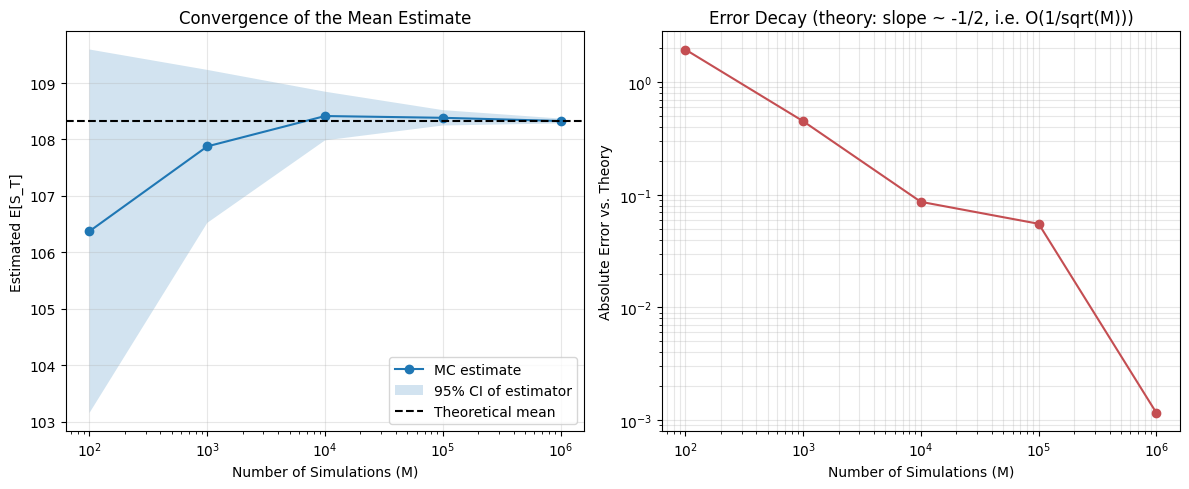

In [11]:
fig, axes = plot_convergence(study)
plt.show()


## 8. Sanity Checks

In [12]:
checks = run_sanity_checks(market, sim_params)
for c in checks:
    status = "PASS" if c.passed else "FAIL"
    print(f"[{status}] {c.name} — {c.detail}")


[PASS] Zero volatility -> deterministic growth — max deviation from S0*exp(mu*T): 0.00e+00
[PASS] Zero drift -> E[S_T] ~= S0 — E[S_T]=99.8203, S0=100.0000, relative error=0.18%
[PASS] E[S_T] ~= S0 * exp(mu*T) — simulated=108.1340, theoretical=108.3287, relative error=0.18%
[PASS] Reproducibility via seed — identical terminal prices across reruns with same seed


## 9. Validation Report

In [13]:
print(generate_validation_report(output))


Monte Carlo Validation Report
──────────────────────────────

Initial Price:        $100.00
Drift:                8.00%
Volatility:           20.00%
Time Horizon:         1.0 year(s)
Simulations:          10,000

Theoretical Mean:     108.33
Simulated Mean:       108.53
Error:                0.19%

Theoretical Std:      21.88
Simulated Std:        21.99

95% CI (of the mean estimator):
[108.10, 108.96]

Convergence: PASS
Reproducibility: PASS
GBM Check: PASS


## 10. Model Limitations

- Constant volatility (no smile/skew, no clustering)
- No jumps (continuous paths only)
- No regime shifts (single μ, σ for the whole horizon)
- No liquidity effects (infinite depth, no market impact)

See `README.md` for the full discussion and the roadmap toward
derivatives pricing and portfolio VaR/ES modules.
